# Diagramas de arquitectura del modelo convolucional 1D

Figuras de la arquitectura del modelo entrenado en `cnn_v1_training.ipynb`, para la memoria. Las dibuja `models/services/architecture_diagram.py`, el módulo que comparten todos los cuadernos de diagramas de `models`:

- La vista `graph` que **visualkeras** saca del modelo ya entrenado, sin escribir la estructura a mano.

La arquitectura descrita es la de `cnn_v1_training.ipynb`, así que hay que repasarla si cambia la red.

In [1]:
import sys

from pathlib import Path

# 'services' cuelga de 'models', así que esa carpeta va a 'sys.path'. 'solution'
# se localiza subiendo desde el directorio de trabajo, sin suponer dónde arranca
# el kernel: su marca es 'pyproject.toml'.
DIRECTORIES = (Path.cwd(), *Path.cwd().parents)
CANDIDATES = (*DIRECTORIES, *(directory / "solution" for directory in DIRECTORIES))
SOLUTION_DIR = next(
    candidate for candidate in CANDIDATES if (candidate / "pyproject.toml").is_file()
)

sys.path.insert(0, str(SOLUTION_DIR / "models"))

from services.architecture_diagram import DIAGRAMS_DIR, draw_diagrams
from services.paths import model_paths

MODEL_PATH = model_paths("cnn_v1", "cnn").model

print("Carpeta de trabajo:", SOLUTION_DIR)
print("Figuras en:", DIAGRAMS_DIR)

2026-09-06 11:44:20.069902: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-09-06 11:44:20.173477: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


2026-09-06 11:44:22.518152: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


Carpeta de trabajo: /home/javier-cacho/repos/master-ia/trabajo-fin-master/solution
Figuras en: /home/javier-cacho/repos/master-ia/trabajo-fin-master/solution/models/images/architectural_diagrams


El `.keras` guarda la arquitectura junto con los pesos. El resumen sirve para comprobar contra el modelo entrenado las formas y el número de filtros que se describen aquí. La vista de visualkeras sí sale del modelo cargado.

In [2]:
import tensorflow as tf

model_cnn = tf.keras.models.load_model(MODEL_PATH)

model_cnn.summary()

2026-09-06 11:44:23.778471: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "cnn_residual_1d"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 2666, 1)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 2666, 64)  │        640 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 2666, 64)  │     28,736 │ conv1d[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_2 (Conv1D)   │ (None, 2666, 64)  │     28,736 │ conv1d_1[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 2666, 64)  │          0 │ conv1d_2[0][0],   │
│                     │                   │            │ conv1d[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 2666, 64)  │          0 │ add[0][0]         │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_3 (Conv1D)   │ (None, 2666, 64)  │     28,736 │ activation[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_4 (Conv1D)   │ (None, 2666, 64)  │     28,736 │ conv1d_3[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 2666, 64)  │          0 │ conv1d_4[0][0],   │
│                     │                   │            │ activation[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 2666, 64)  │          0 │ add_1[0][0]       │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_5 (Conv1D)   │ (None, 2666, 64)  │     28,736 │ activation_1[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_6 (Conv1D)   │ (None, 2666, 64)  │     28,736 │ conv1d_5[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_2 (Add)         │ (None, 2666, 64)  │          0 │ conv1d_6[0][0],   │
│                     │                   │            │ activation_1[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 2666, 64)  │          0 │ add_2[0][0]       │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_7 (Conv1D)   │ (None, 2666, 64)  │     28,736 │ activation_2[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_8 (Conv1D)   │ (None, 2666, 64)  │     28,736 │ conv1d_7[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_3 (Add)         │ (None, 2666, 64)  │          0 │ conv1d_8[0][0],   │
│                     │                   │            │ activation_2[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 2666, 64)  │          0 │ add_3[0][0]       │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_9 (Conv1D)   │ (None, 2666, 1)   │        321 │ activation_3[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_4 (Add)         │ (None, 2666, 1)   │          0 │ input_layer[0][0… │
│                     │                   │            │ conv1d_9[0][0]  

 Total params: 692,549 (2.64 MB)

 Trainable params: 230,849 (901.75 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 461,700 (1.76 MB)

La arquitectura de la red es la siguiente:

- La red trabaja siempre sobre la malla de SDSS, sin submuestrear: los 2666 puntos se conservan de principio a fin, y por eso la red es una cadena y no una U como la de la v2.
- Tras la convolución inicial de 64 filtros vienen los **cuatro bloques residuales**, todos iguales, que la figura agrupa en una sola caja: lo que cambia entre ellos son los pesos, no la forma.
- La convolución final de un filtro genera la **corrección**, y la **conexión residual global** —la flecha discontinua— le suma el flujo interpolado: la red aprende la corrección, no el espectro entero.

Cada bloque residual son dos convoluciones, el atajo que se les suma y la activación.

Y cómo se lee la vista `graph` de visualkeras, que salen del `.keras` y por tanto enseñan la red tal y como quedó y no como se pretendía que fuera:

- `graph`: las neuronas de cada capa y las conexiones entre ellas, resumidas con puntos suspensivos.

/home/javier-cacho/repos/master-ia/trabajo-fin-master/solution/services/architecture_diagram.py:348: UserWarning: graph_view received many custom keyword arguments. Consider using visualkeras.show(..., mode='graph', preset=...) and the GraphOptions dataclass for a simpler workflow.
  render(


Diagrama guardado en: /home/javier-cacho/repos/master-ia/trabajo-fin-master/solution/models/images/architectural_diagrams/cnn_v1_graph-diagram.png


/home/javier-cacho/repos/master-ia/trabajo-fin-master/solution/services/architecture_diagram.py:348: UserWarning: layered_view received many custom keyword arguments. Consider using visualkeras.show(..., preset=...) for a simpler workflow.
  render(
/home/javier-cacho/repos/master-ia/trabajo-fin-master/solution/services/architecture_diagram.py:348: UserWarning: Custom text_callable detected. Built-in caption templates are available via visualkeras.show(..., text_callable='name').
  render(
/home/javier-cacho/repos/master-ia/trabajo-fin-master/solution/.venv/lib/python3.13/site-packages/visualkeras/layered.py:820: UserWarning: The legend_text_spacing_offset parameter is deprecated and will be removed in a future release.
  warnings.warn("The legend_text_spacing_offset parameter is deprecated and will be removed in a future release.")


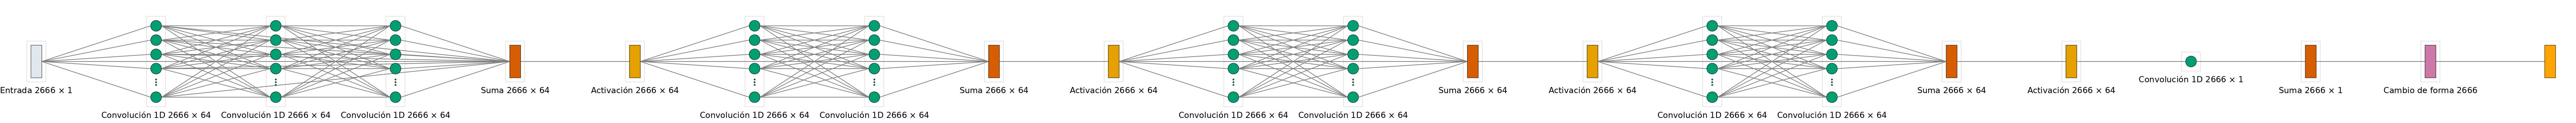

Diagrama guardado en: /home/javier-cacho/repos/master-ia/trabajo-fin-master/solution/models/images/architectural_diagrams/cnn_v1_layered-diagram.png


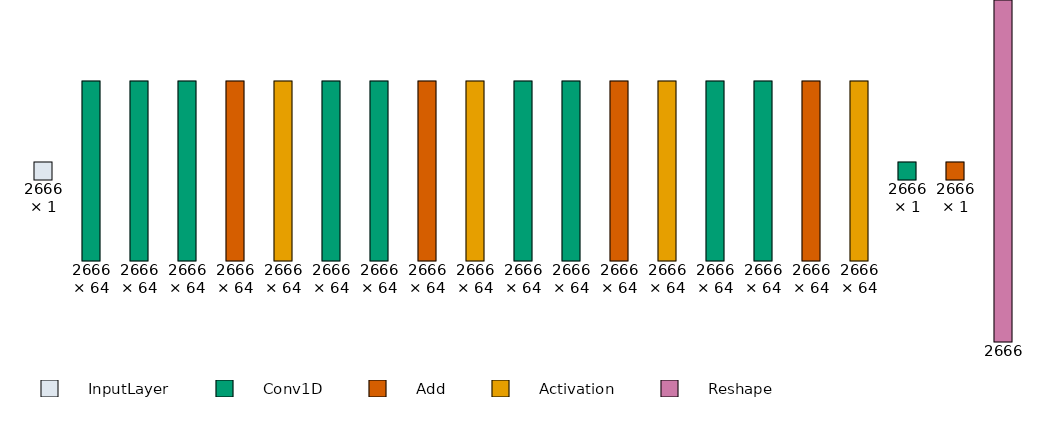

{'graph': PosixPath('/home/javier-cacho/repos/master-ia/trabajo-fin-master/solution/models/images/architectural_diagrams/cnn_v1_graph-diagram.png'),
 'layered': PosixPath('/home/javier-cacho/repos/master-ia/trabajo-fin-master/solution/models/images/architectural_diagrams/cnn_v1_layered-diagram.png')}

In [3]:
draw_diagrams(model_cnn, "cnn_v1", views=("graph", "layered"))